In [1]:
import hea
import numpy as np

## Examples from *R for Data Science* (2023)

### Chapter 1

In [2]:
penguins = hea.data("penguins", package="palmerpenguins")
penguins.glimpse()

Rows: 344
Columns: 8
$ species           <str> 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie'
$ island            <str> 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen'
$ bill_length_mm    <f64> 39.1, 39.5, 40.3, null, 36.7, 39.3, 38.9, 39.2, 34.1, 42.0
$ bill_depth_mm     <f64> 18.7, 17.4, 18.0, null, 19.3, 20.6, 17.8, 19.6, 18.1, 20.2
$ flipper_length_mm <f64> 181.0, 186.0, 195.0, null, 193.0, 190.0, 181.0, 195.0, 193.0, 190.0
$ body_mass_g       <f64> 3750.0, 3800.0, 3250.0, null, 3450.0, 3650.0, 3625.0, 4675.0, 3475.0, 4250.0
$ sex               <str> 'male', 'female', 'female', null, 'female', 'male', 'female', 'male', null, null
$ year              <i64> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007



/Users/ziweih/Works/hea/hea/ggplot/core.py:182: UserWarning: Removed 2 rows containing missing values (`geom_point()`).
  fig = self.draw()
/Users/ziweih/Works/hea/hea/ggplot/core.py:182: UserWarning: Removed 2 rows containing missing values (`geom_smooth()`).
  fig = self.draw()


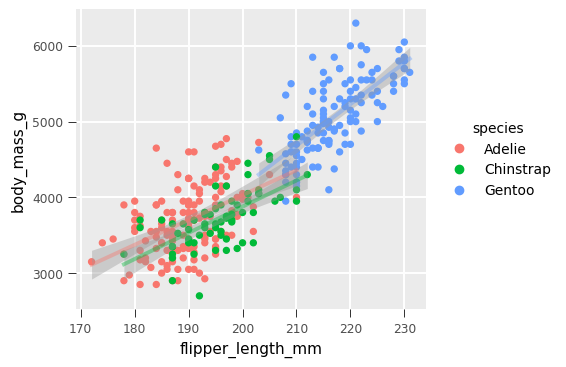

In [3]:
from hea.ggplot import aes
(
    penguins
        .ggplot(
            mapping=aes(
                x="flipper_length_mm", 
                y="body_mass_g",
                color="species"
            )
        )
        .geom_point()
        .geom_smooth(method="lm")
)

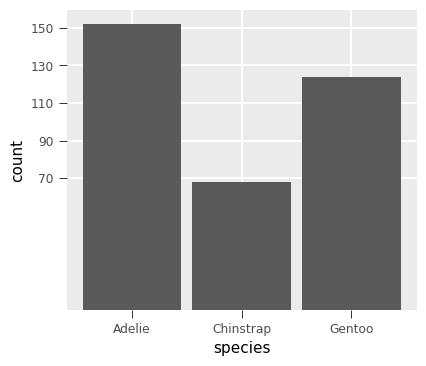

In [4]:
penguins.ggplot(aes(x="species")).geom_bar()

/Users/ziweih/Works/hea/hea/ggplot/_block.py:757: UserWarning: Removed 2 rows containing missing values (`geom_bar()`).
  cells[r][c] = (child, compute_block(child))


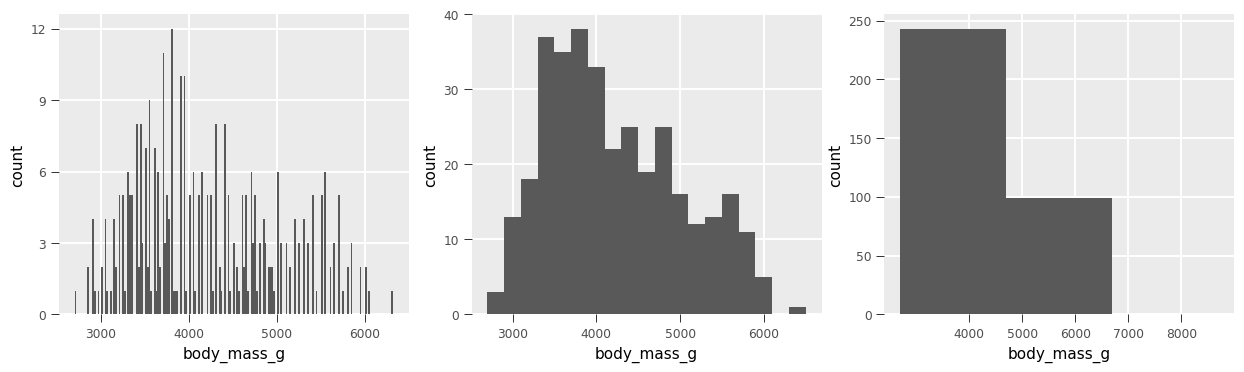

In [5]:
p1 = penguins.ggplot(aes(x ="body_mass_g")).geom_histogram(binwidth = 20)
p2 = penguins.ggplot(aes(x ="body_mass_g")).geom_histogram(binwidth = 200)
p3 = penguins.ggplot(aes(x ="body_mass_g")).geom_histogram(binwidth = 2000)
p1 + p2 + p3

/Users/ziweih/Works/hea/hea/ggplot/core.py:182: UserWarning: Removed 2 rows containing missing values (`geom_density()`).
  fig = self.draw()


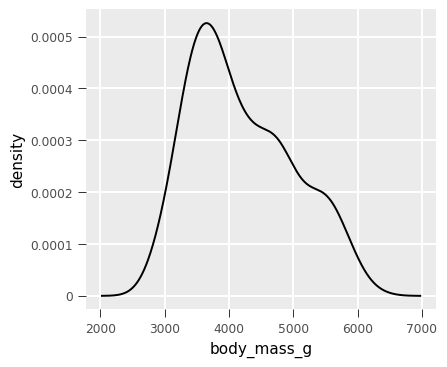

In [6]:
penguins.ggplot(aes(x="body_mass_g")).geom_density()

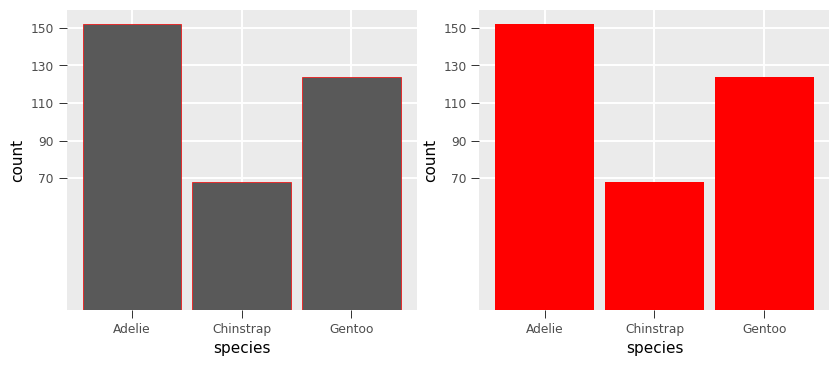

In [7]:
p1 = penguins.ggplot(aes(x="species")).geom_bar(color="red")
p2 = penguins.ggplot(aes(x="species")).geom_bar(fill="red")
p1 + p2

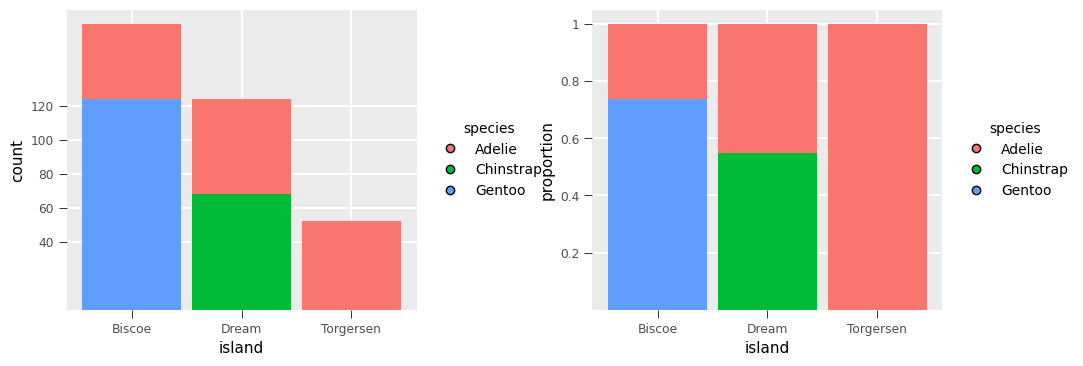

In [8]:
penguins = hea.data("penguins", package="palmerpenguins")
p1 = penguins.ggplot(aes(x="island", fill="species")).geom_bar()
p2 = penguins.ggplot(aes(x="island", fill="species")).geom_bar(position="fill").labs(y="proportion")
p1 | p2

### Chapter 3

In [9]:
flights = hea.data("flights", package="nycflights13")
flights

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [10]:
out = (
    flights
        .filter(hea.col("dest") == "IAH")
        .group_by("year", "month", "day")
        .summarize(arr_delay=hea.col("arr_delay").mean())
)

In [11]:
out

year,month,day,arr_delay
i64,i64,i64,f64
2013,1,1,17.85
2013,1,2,7.0
2013,1,3,18.315789
2013,1,4,-3.2
2013,1,5,20.230769
…,…,…,…
2013,9,26,-16.857143
2013,9,27,-26.545455
2013,9,28,-27.133333


In [12]:
flights.filter(hea.col("dep_delay") > 120)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,848.0,1835,853.0,1001.0,1950,851.0,"""MQ""",3944,"""N942MQ""","""JFK""","""BWI""",41.0,184,18,35,"""2013-01-01T23:00:00Z"""
2013,1,1,957.0,733,144.0,1056.0,853,123.0,"""UA""",856,"""N534UA""","""EWR""","""BOS""",37.0,200,7,33,"""2013-01-01T12:00:00Z"""
2013,1,1,1114.0,900,134.0,1447.0,1222,145.0,"""UA""",1086,"""N76502""","""LGA""","""IAH""",248.0,1416,9,0,"""2013-01-01T14:00:00Z"""
2013,1,1,1540.0,1338,122.0,2020.0,1825,115.0,"""B6""",705,"""N570JB""","""JFK""","""SJU""",193.0,1598,13,38,"""2013-01-01T18:00:00Z"""
2013,1,1,1815.0,1325,290.0,2120.0,1542,338.0,"""EV""",4417,"""N17185""","""EWR""","""OMA""",213.0,1134,13,25,"""2013-01-01T18:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,1823.0,1545,158.0,1934.0,1733,121.0,"""9E""",3459,"""N916XJ""","""JFK""","""BNA""",95.0,765,15,45,"""2013-09-30T19:00:00Z"""
2013,9,30,1951.0,1649,182.0,2157.0,1903,174.0,"""EV""",4294,"""N13988""","""EWR""","""SAV""",95.0,708,16,49,"""2013-09-30T20:00:00Z"""
2013,9,30,2053.0,1815,158.0,2310.0,2054,136.0,"""EV""",5292,"""N600QX""","""EWR""","""ATL""",91.0,746,18,15,"""2013-09-30T22:00:00Z"""


In [13]:
flights.filter((hea.col("month") == 1) & (hea.col("day") == 1))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,1,1,2356.0,2359,-3.0,425.0,437,-12.0,"""B6""",727,"""N588JB""","""JFK""","""BQN""",186.0,1576,23,59,"""2013-01-02T04:00:00Z"""
2013,1,1,null,1630,null,null,1815,null,"""EV""",4308,"""N18120""","""EWR""","""RDU""",null,416,16,30,"""2013-01-01T21:00:00Z"""
2013,1,1,null,1935,null,null,2240,null,"""AA""",791,"""N3EHAA""","""LGA""","""DFW""",null,1389,19,35,"""2013-01-02T00:00:00Z"""


In [14]:
flights.filter((hea.col("month") == 1) | (hea.col("month") == 2))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,2,28,null,850,null,null,1035,null,"""MQ""",4558,"""N737MQ""","""LGA""","""CLE""",null,419,8,50,"""2013-02-28T13:00:00Z"""
2013,2,28,null,905,null,null,1115,null,"""MQ""",4478,"""N722MQ""","""LGA""","""DTW""",null,502,9,5,"""2013-02-28T14:00:00Z"""
2013,2,28,null,1115,null,null,1310,null,"""MQ""",4485,"""N725MQ""","""LGA""","""CMH""",null,479,11,15,"""2013-02-28T16:00:00Z"""


In [15]:
flights.filter(hea.col("month").is_in([1, 2]))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,2,28,null,850,null,null,1035,null,"""MQ""",4558,"""N737MQ""","""LGA""","""CLE""",null,419,8,50,"""2013-02-28T13:00:00Z"""
2013,2,28,null,905,null,null,1115,null,"""MQ""",4478,"""N722MQ""","""LGA""","""DTW""",null,502,9,5,"""2013-02-28T14:00:00Z"""
2013,2,28,null,1115,null,null,1310,null,"""MQ""",4485,"""N725MQ""","""LGA""","""CMH""",null,479,11,15,"""2013-02-28T16:00:00Z"""


In [16]:
jan1 = flights.filter(hea.col("month") == 1, hea.col("day") == 1)

In [17]:
jan1

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,1,1,2356.0,2359,-3.0,425.0,437,-12.0,"""B6""",727,"""N588JB""","""JFK""","""BQN""",186.0,1576,23,59,"""2013-01-02T04:00:00Z"""
2013,1,1,null,1630,null,null,1815,null,"""EV""",4308,"""N18120""","""EWR""","""RDU""",null,416,16,30,"""2013-01-01T21:00:00Z"""
2013,1,1,null,1935,null,null,2240,null,"""AA""",791,"""N3EHAA""","""LGA""","""DFW""",null,1389,19,35,"""2013-01-02T00:00:00Z"""


In [18]:
flights.arrange("year", "month", "day", "dep_time")

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,12,31,null,705,null,null,931,null,"""UA""",1729,null,"""EWR""","""DEN""",null,1605,7,5,"""2013-12-31T12:00:00Z"""
2013,12,31,null,825,null,null,1029,null,"""US""",1831,null,"""JFK""","""CLT""",null,541,8,25,"""2013-12-31T13:00:00Z"""
2013,12,31,null,1615,null,null,1800,null,"""MQ""",3301,"""N844MQ""","""LGA""","""RDU""",null,431,16,15,"""2013-12-31T21:00:00Z"""


In [19]:
flights.arrange(hea.desc("dep_delay"))

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,9,641.0,900,1301.0,1242.0,1530,1272.0,"""HA""",51,"""N384HA""","""JFK""","""HNL""",640.0,4983,9,0,"""2013-01-09T14:00:00Z"""
2013,6,15,1432.0,1935,1137.0,1607.0,2120,1127.0,"""MQ""",3535,"""N504MQ""","""JFK""","""CMH""",74.0,483,19,35,"""2013-06-15T23:00:00Z"""
2013,1,10,1121.0,1635,1126.0,1239.0,1810,1109.0,"""MQ""",3695,"""N517MQ""","""EWR""","""ORD""",111.0,719,16,35,"""2013-01-10T21:00:00Z"""
2013,9,20,1139.0,1845,1014.0,1457.0,2210,1007.0,"""AA""",177,"""N338AA""","""JFK""","""SFO""",354.0,2586,18,45,"""2013-09-20T22:00:00Z"""
2013,7,22,845.0,1600,1005.0,1044.0,1815,989.0,"""MQ""",3075,"""N665MQ""","""JFK""","""CVG""",96.0,589,16,0,"""2013-07-22T20:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [20]:
flights.distinct()

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [21]:
flights.distinct("origin", "dest")

origin,dest
str,str
"""EWR""","""IAH"""
"""LGA""","""IAH"""
"""JFK""","""MIA"""
"""JFK""","""BQN"""
"""LGA""","""ATL"""
…,…
"""LGA""","""TVC"""
"""LGA""","""MYR"""
"""EWR""","""TVC"""


In [22]:
flights.distinct("origin", "dest", keep_all=True)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,6,14,1756.0,1800,-4.0,2004.0,2005,-1.0,"""MQ""",3402,"""N722MQ""","""LGA""","""TVC""",101.0,655,18,0,"""2013-06-14T22:00:00Z"""
2013,6,15,1517.0,1520,-3.0,1656.0,1730,-34.0,"""EV""",5163,"""N605QX""","""LGA""","""MYR""",74.0,563,15,20,"""2013-06-15T19:00:00Z"""
2013,7,5,1355.0,1400,-5.0,1550.0,1620,-30.0,"""EV""",4137,"""N11164""","""EWR""","""TVC""",93.0,644,14,0,"""2013-07-05T18:00:00Z"""


In [23]:
flights.mutate(
    gain=hea.col("dep_delay") - hea.col("arr_delay"),
    speed=hea.col("distance") / hea.col("air_time") * 60,
)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,gain,speed
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str,f64,f64
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z""",-9.0,370.044053
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z""",-16.0,374.273128
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z""",-31.0,408.375
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z""",17.0,516.721311
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z""",19.0,394.137931
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z""",null,null
2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z""",null,null
2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z""",null,null


In [24]:
flights.mutate(
    gain=hea.col("dep_delay") - hea.col("arr_delay"),
    speed=hea.col("distance") / hea.col("air_time") * 60,
    _before=1,
)

gain,speed,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
f64,f64,i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
-9.0,370.044053,2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
-16.0,374.273128,2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
-31.0,408.375,2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
17.0,516.721311,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
19.0,394.137931,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,null,2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
null,null,2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
null,null,2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [25]:
flights.mutate(
    gain=hea.col("dep_delay") - hea.col("arr_delay"),
    speed=hea.col("distance") / hea.col("air_time") * 60,
    _after="day"
)

year,month,day,gain,speed,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,f64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,-9.0,370.044053,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,-16.0,374.273128,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,-31.0,408.375,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,17.0,516.721311,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,19.0,394.137931,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,null,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,null,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,null,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [26]:
flights.mutate(
    **{
        "gain": hea.col("dep_delay") - hea.col("arr_delay"),
        "hours": (hea.col("air_time") / 60),
        "gain.per.hour": (hea.col("gain") / hea.col("hours")),
    },
    _keep="used"
)
# or use alias if you don't like **{...}
# flights.mutate(
#     (hea.col("dep_delay") - hea.col("arr_delay")).alias("gain"),
#     (hea.col("air_time") / 60).alias("hours"),
#     (hea.col("gain") / hea.col("hours")).alias("gain.per.hour"),
#     _keep="used"
# )


dep_delay,arr_delay,air_time,gain,hours,gain.per.hour
f64,f64,f64,f64,f64,f64
2.0,11.0,227.0,-9.0,3.783333,-2.378855
4.0,20.0,227.0,-16.0,3.783333,-4.229075
2.0,33.0,160.0,-31.0,2.666667,-11.625
-1.0,-18.0,183.0,17.0,3.05,5.57377
-6.0,-25.0,116.0,19.0,1.933333,9.827586
…,…,…,…,…,…
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null


In [27]:
flights.select("year", "month", "day")

year,month,day
i64,i64,i64
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
…,…,…
2013,9,30
2013,9,30
2013,9,30


In [28]:
flights.select(flights.cols_between("year", "day"))

year,month,day
i64,i64,i64
2013,1,1
2013,1,1
2013,1,1
2013,1,1
2013,1,1
…,…,…
2013,9,30
2013,9,30
2013,9,30


In [29]:
flights.select(hea.exclude(flights.cols_between("year", "day")))

dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [30]:
flights.select(hea.selectors.string())

carrier,tailnum,origin,dest,time_hour
str,str,str,str,str
"""UA""","""N14228""","""EWR""","""IAH""","""2013-01-01T10:00:00Z"""
"""UA""","""N24211""","""LGA""","""IAH""","""2013-01-01T10:00:00Z"""
"""AA""","""N619AA""","""JFK""","""MIA""","""2013-01-01T10:00:00Z"""
"""B6""","""N804JB""","""JFK""","""BQN""","""2013-01-01T10:00:00Z"""
"""DL""","""N668DN""","""LGA""","""ATL""","""2013-01-01T11:00:00Z"""
…,…,…,…,…
"""9E""",null,"""JFK""","""DCA""","""2013-09-30T18:00:00Z"""
"""9E""",null,"""LGA""","""SYR""","""2013-10-01T02:00:00Z"""
"""MQ""","""N535MQ""","""LGA""","""BNA""","""2013-09-30T16:00:00Z"""


In [31]:
flights.select(tail_num="tailnum")

tail_num
str
"""N14228"""
"""N24211"""
"""N619AA"""
"""N804JB"""
"""N668DN"""
…
null
null
"""N535MQ"""


In [32]:
np.vstack([flights.columns, flights.rename(tail_num="tailnum").columns]).T

array([['year', 'year'],
       ['month', 'month'],
       ['day', 'day'],
       ['dep_time', 'dep_time'],
       ['sched_dep_time', 'sched_dep_time'],
       ['dep_delay', 'dep_delay'],
       ['arr_time', 'arr_time'],
       ['sched_arr_time', 'sched_arr_time'],
       ['arr_delay', 'arr_delay'],
       ['carrier', 'carrier'],
       ['flight', 'flight'],
       ['tailnum', 'tail_num'],
       ['origin', 'origin'],
       ['dest', 'dest'],
       ['air_time', 'air_time'],
       ['distance', 'distance'],
       ['hour', 'hour'],
       ['minute', 'minute'],
       ['time_hour', 'time_hour']], dtype='<U14')

In [33]:
flights.relocate("time_hour", "air_time")

air_time,time_hour,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,distance,hour,minute
f64,str,i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,i64,i64,i64
227.0,"""2013-01-01T10:00:00Z""",2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",1400,5,15
227.0,"""2013-01-01T10:00:00Z""",2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",1416,5,29
160.0,"""2013-01-01T10:00:00Z""",2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",1089,5,40
183.0,"""2013-01-01T10:00:00Z""",2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",1576,5,45
116.0,"""2013-01-01T11:00:00Z""",2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",762,6,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,"""2013-09-30T18:00:00Z""",2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",213,14,55
null,"""2013-10-01T02:00:00Z""",2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",198,22,0
null,"""2013-09-30T16:00:00Z""",2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",764,12,10


In [34]:
flights.relocate(flights.cols_between("year", "dep_time"), _after="time_hour")

sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,year,month,day,dep_time
i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str,i64,i64,i64,f64
515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z""",2013,1,1,517.0
529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z""",2013,1,1,533.0
540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z""",2013,1,1,542.0
545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z""",2013,1,1,544.0
600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z""",2013,1,1,554.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z""",2013,9,30,null
2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z""",2013,9,30,null
1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z""",2013,9,30,null


In [35]:
flights.relocate(hea.selectors.starts_with("arr"), _before="dep_time")

year,month,day,arr_time,arr_delay,dep_time,sched_dep_time,dep_delay,sched_arr_time,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,f64,f64,i64,f64,i64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,830.0,11.0,517.0,515,2.0,819,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,850.0,20.0,533.0,529,4.0,830,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,923.0,33.0,542.0,540,2.0,850,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,1004.0,-18.0,544.0,545,-1.0,1022,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,812.0,-25.0,554.0,600,-6.0,837,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,null,null,1455,null,1634,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,null,null,2200,null,2312,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,null,null,1210,null,1330,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [36]:
(
    flights
        .filter(hea.col("dest") == "IAH")
        .mutate(speed=hea.col("distance") / hea.col("air_time") * 60)
        .select(flights.cols_between("year", "day"), "dep_time", "carrier", "flight", "speed")
        .arrange(hea.desc("speed"))
)

year,month,day,dep_time,carrier,flight,speed
i64,i64,i64,f64,str,i64,f64
2013,7,9,707.0,"""UA""",226,521.73913
2013,8,27,1850.0,"""UA""",1128,521.226994
2013,8,28,902.0,"""UA""",1711,518.518519
2013,8,28,2122.0,"""UA""",1022,518.518519
2013,6,11,1628.0,"""UA""",1178,515.337423
…,…,…,…,…,…,…
2013,9,12,1815.0,"""UA""",1695,null
2013,9,12,null,"""UA""",404,null
2013,9,12,null,"""UA""",525,null


In [37]:
(
    flights
        .group_by("month")
        .summarize(
            avg_delay=hea.col("dep_delay").mean()
        )
)

month,avg_delay
i64,f64
1,10.036665
10,6.243988
11,5.435362
12,16.576688
2,10.816843
…,…
5,12.986859
6,20.846332
7,21.727787


In [38]:
(
    flights
        .group_by("month")
        .summarize(
            delay=hea.col("dep_delay").mean(),
            n=hea.len(),
        )
)

month,delay,n
i64,f64,u32
1,10.036665,27004
10,6.243988,28889
11,5.435362,27268
12,16.576688,28135
2,10.816843,24951
…,…,…
5,12.986859,28796
6,20.846332,28243
7,21.727787,29425


In [39]:
(
    flights
        .group_by("dest")
        .slice_max("arr_delay", n=1)
        .relocate("dest")
)

dest,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,air_time,distance,hour,minute,time_hour
str,i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,f64,i64,i64,i64,str
"""ABQ""",2013,7,22,2145.0,2007,98.0,132.0,2259,153.0,"""B6""",1505,"""N784JB""","""JFK""",259.0,1826,20,7,"""2013-07-23T00:00:00Z"""
"""ACK""",2013,7,23,1139.0,800,219.0,1250.0,909,221.0,"""B6""",1491,"""N192JB""","""JFK""",44.0,199,8,0,"""2013-07-23T12:00:00Z"""
"""ALB""",2013,1,25,123.0,2000,323.0,229.0,2101,328.0,"""EV""",4309,"""N13908""","""EWR""",30.0,143,20,0,"""2013-01-26T01:00:00Z"""
"""ANC""",2013,8,17,1740.0,1625,75.0,2042.0,2003,39.0,"""UA""",887,"""N528UA""","""EWR""",404.0,3370,16,25,"""2013-08-17T20:00:00Z"""
"""ATL""",2013,7,22,2257.0,759,898.0,121.0,1026,895.0,"""DL""",2047,"""N6716C""","""LGA""",109.0,762,7,59,"""2013-07-22T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""TPA""",2013,4,10,1100.0,1900,960.0,1342.0,2211,931.0,"""DL""",2391,"""N959DL""","""JFK""",139.0,1005,19,0,"""2013-04-10T23:00:00Z"""
"""TUL""",2013,1,20,2347.0,1936,251.0,230.0,2208,262.0,"""EV""",4333,"""N14177""","""EWR""",208.0,1215,19,36,"""2013-01-21T00:00:00Z"""
"""TVC""",2013,8,10,1120.0,730,230.0,1323.0,943,220.0,"""EV""",5144,"""N718EV""","""LGA""",96.0,655,7,30,"""2013-08-10T11:00:00Z"""


In [40]:
daily = (
    flights
        .group_by("year", "month", "day")
)

In [41]:
daily_flights = daily.summarize(n=hea.len())
daily_flights

year,month,day,n
i64,i64,i64,u32
2013,1,1,842
2013,1,2,943
2013,1,3,914
2013,1,4,915
2013,1,5,720
…,…,…,…
2013,9,26,996
2013,9,27,996
2013,9,28,682


In [42]:
daily.ungroup()

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
i64,i64,i64,f64,i64,f64,f64,i64,f64,str,i64,str,str,str,f64,i64,i64,i64,str
2013,1,1,517.0,515,2.0,830.0,819,11.0,"""UA""",1545,"""N14228""","""EWR""","""IAH""",227.0,1400,5,15,"""2013-01-01T10:00:00Z"""
2013,1,1,533.0,529,4.0,850.0,830,20.0,"""UA""",1714,"""N24211""","""LGA""","""IAH""",227.0,1416,5,29,"""2013-01-01T10:00:00Z"""
2013,1,1,542.0,540,2.0,923.0,850,33.0,"""AA""",1141,"""N619AA""","""JFK""","""MIA""",160.0,1089,5,40,"""2013-01-01T10:00:00Z"""
2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,"""B6""",725,"""N804JB""","""JFK""","""BQN""",183.0,1576,5,45,"""2013-01-01T10:00:00Z"""
2013,1,1,554.0,600,-6.0,812.0,837,-25.0,"""DL""",461,"""N668DN""","""LGA""","""ATL""",116.0,762,6,0,"""2013-01-01T11:00:00Z"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013,9,30,null,1455,null,null,1634,null,"""9E""",3393,null,"""JFK""","""DCA""",null,213,14,55,"""2013-09-30T18:00:00Z"""
2013,9,30,null,2200,null,null,2312,null,"""9E""",3525,null,"""LGA""","""SYR""",null,198,22,0,"""2013-10-01T02:00:00Z"""
2013,9,30,null,1210,null,null,1330,null,"""MQ""",3461,"""N535MQ""","""LGA""","""BNA""",null,764,12,10,"""2013-09-30T16:00:00Z"""


In [43]:
daily.ungroup().summarize(
    avg_delay=hea.col("dep_delay").mean(),
    flights=hea.len()
)

avg_delay,flights
f64,u32
12.63907,336776


In [44]:
flights.summarize(
    delay=hea.col("dep_delay").mean(),
    n=hea.len(),
    _by="month"
)

month,delay,n
i64,f64,u32
1,10.036665,27004
10,6.243988,28889
11,5.435362,27268
12,16.576688,28135
2,10.816843,24951
…,…,…
5,12.986859,28796
6,20.846332,28243
7,21.727787,29425


In [45]:
flights.summarize(
    delay=hea.col("dep_delay").mean(),
    n=hea.len(),
    _by=["origin", "dest"]
)

origin,dest,delay,n
str,str,f64,u32
"""EWR""","""IAH""",11.826551,3973
"""LGA""","""IAH""",9.058986,2951
"""JFK""","""MIA""",9.336571,3314
"""JFK""","""BQN""",6.665546,599
"""LGA""","""ATL""",11.448621,10263
…,…,…,…
"""LGA""","""TVC""",23.410959,77
"""LGA""","""MYR""",0.666667,3
"""EWR""","""TVC""",17.869565,24


### Chapter 5

In [46]:
table1 = hea.data("table1", package="tidyr")
table2 = hea.data("table2", package="tidyr")
table3 = hea.data("table3", package="tidyr")

In [47]:
table1.mutate(rate=hea.col("cases") / hea.col("population") * 10_000)

country,year,cases,population,rate
str,i64,i64,i64,f64
"""Afghanistan""",1999,745,19987071,0.372741
"""Afghanistan""",2000,2666,20595360,1.294466
"""Brazil""",1999,37737,172006362,2.19393
"""Brazil""",2000,80488,174504898,4.612363
"""China""",1999,212258,1272915272,1.667495
"""China""",2000,213766,1280428583,1.669488


In [48]:
table1.group_by("year").summarize(total_cases=hea.col("cases").sum())

year,total_cases
i64,i64
1999,250740
2000,296920


In [49]:
billboard = hea.data("billboard", "tidyr")
billboard

artist,track,date.entered,wk1,wk2,wk3,wk4,wk5,wk6,wk7,wk8,wk9,wk10,wk11,wk12,wk13,wk14,wk15,wk16,wk17,wk18,wk19,wk20,wk21,wk22,wk23,wk24,wk25,wk26,wk27,wk28,wk29,wk30,wk31,wk32,wk33,wk34,…,wk40,wk41,wk42,wk43,wk44,wk45,wk46,wk47,wk48,wk49,wk50,wk51,wk52,wk53,wk54,wk55,wk56,wk57,wk58,wk59,wk60,wk61,wk62,wk63,wk64,wk65,wk66,wk67,wk68,wk69,wk70,wk71,wk72,wk73,wk74,wk75,wk76
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""",87,82.0,72.0,77.0,87.0,94.0,99.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2Ge+her""","""The Hardest Part Of ...""","""2000-09-02""",91,87.0,92.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""3 Doors Down""","""Kryptonite""","""2000-04-08""",81,70.0,68.0,67.0,66.0,57.0,54.0,53.0,51.0,51.0,51.0,51.0,47.0,44.0,38.0,28.0,22.0,18.0,18.0,14.0,12.0,7.0,6.0,6.0,6.0,5.0,5.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,…,15.0,14.0,13.0,14.0,16.0,17.0,21.0,22.0,24.0,28.0,33.0,42.0,42.0,49.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""3 Doors Down""","""Loser""","""2000-10-21""",76,76.0,72.0,69.0,67.0,65.0,55.0,59.0,62.0,61.0,61.0,59.0,61.0,66.0,72.0,76.0,75.0,67.0,73.0,70.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""504 Boyz""","""Wobble Wobble""","""2000-04-15""",57,34.0,25.0,17.0,17.0,31.0,36.0,49.0,53.0,57.0,64.0,70.0,75.0,76.0,78.0,85.0,92.0,96.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Yankee Grey""","""Another Nine Minutes""","""2000-04-29""",86,83.0,77.0,74.0,83.0,79.0,88.0,95.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Yearwood, Trisha""","""Real Live Woman""","""2000-04-01""",85,83.0,83.0,82.0,81.0,91.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Ying Yang Twins""","""Whistle While You Tw...""","""2000-03-18""",95,94.0,91.0,85.0,84.0,78.0,74.0,78.0,85.0,89.0,97.0,96.0,99.0,99.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,

In [50]:
billboard.pivot_longer(
    cols=hea.selectors.starts_with("wk"),
    names_to="week",
    values_to="rank",
)

artist,track,date.entered,week,rank
str,str,str,str,f64
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk1""",87.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk2""",82.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk3""",72.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk4""",77.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk5""",87.0
…,…,…,…,…
"""matchbox twenty""","""Bent""","""2000-04-29""","""wk72""",null
"""matchbox twenty""","""Bent""","""2000-04-29""","""wk73""",null
"""matchbox twenty""","""Bent""","""2000-04-29""","""wk74""",null


In [51]:
billboard.pivot_longer(
    cols=hea.selectors.starts_with("wk"),
    names_to="week",
    values_to="rank",
    values_drop_na=True,
)

artist,track,date.entered,week,rank
str,str,str,str,f64
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk1""",87.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk2""",82.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk3""",72.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk4""",77.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""","""wk5""",87.0
…,…,…,…,…
"""matchbox twenty""","""Bent""","""2000-04-29""","""wk35""",33.0
"""matchbox twenty""","""Bent""","""2000-04-29""","""wk36""",37.0
"""matchbox twenty""","""Bent""","""2000-04-29""","""wk37""",38.0


In [52]:
billboard_longer = (
    billboard.pivot_longer(
        cols=hea.selectors.starts_with("wk"),
        names_to="week",
        values_to="rank",
        values_drop_na=True,
        names_prefix="wk",
    ).mutate(
        week=hea.col("week").cast(hea.Int64)
    )
)


In [53]:
billboard_longer

artist,track,date.entered,week,rank
str,str,str,i64,f64
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""",1,87.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""",2,82.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""",3,72.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""",4,77.0
"""2 Pac""","""Baby Don't Cry (Keep...""","""2000-02-26""",5,87.0
…,…,…,…,…
"""matchbox twenty""","""Bent""","""2000-04-29""",35,33.0
"""matchbox twenty""","""Bent""","""2000-04-29""",36,37.0
"""matchbox twenty""","""Bent""","""2000-04-29""",37,38.0


In [54]:
who2 = hea.data("who2", "tidyr")
who2

country,year,sp_m_014,sp_m_1524,sp_m_2534,sp_m_3544,sp_m_4554,sp_m_5564,sp_m_65,sp_f_014,sp_f_1524,sp_f_2534,sp_f_3544,sp_f_4554,sp_f_5564,sp_f_65,sn_m_014,sn_m_1524,sn_m_2534,sn_m_3544,sn_m_4554,sn_m_5564,sn_m_65,sn_f_014,sn_f_1524,sn_f_2534,sn_f_3544,sn_f_4554,sn_f_5564,sn_f_65,ep_m_014,ep_m_1524,ep_m_2534,ep_m_3544,ep_m_4554,ep_m_5564,ep_m_65,ep_f_014,ep_f_1524,ep_f_2534,ep_f_3544,ep_f_4554,ep_f_5564,ep_f_65,rel_m_014,rel_m_1524,rel_m_2534,rel_m_3544,rel_m_4554,rel_m_5564,rel_m_65,rel_f_014,rel_f_1524,rel_f_2534,rel_f_3544,rel_f_4554,rel_f_5564,rel_f_65
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""",1980,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Afghanistan""",1981,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Afghanistan""",1982,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Afghanistan""",1983,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Afghanistan""",1984,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2009,125.0,578.0,null,3471.0,681.0,293.0,192.0,180.0,873.0,null,3028.0,419.0,229.0,126.0,1560.0,860.0,null,6496.0,1655.0,882.0,861.0,1425.0,1334.0,null,7023.0,1551.0,729.0,514.0,244.0,266.0,0.0,1922.0,491.0,231.0,223.0,210.0,394.0,0.0,1944.0,438.0,182.0,138.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Zimbabwe""",2010,150.0,710.0,2208.0,1682.0,761.0,350.0,252.0,173.0,974.0,2185.0,1283.0,490.0,265.0,171.0,1826.0,821.0,3342.0,3270.0,1545.0,882.0,864.0,1732.0,1282.0,4013.0,2851.0,1377.0,789.0,563.0,270.0,243.0,902.0,868.0,418.0,229.0,192.0,220.0,319.0,1058.0,677.0,338.0,181.0,146.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Zimbabwe""",2011,152.0,784.0,2467.0,2071.0,780.0,377.0,278.0,174.0,1084.0,2161.0,1386.0,448.0,274.0,160.0,1364.0,596.0,2473.0,2813.0,1264.0,702.0,728.0,1271.0,947.0,2754.0,2216.0,962.0,587.0,495.0,250.0,195.0,746.0,796.0,342.0,172.0,172.0,209.0,318.0,802.0,640.0,284.0,137.0,129.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [55]:
(
    who2
        .pivot_longer(
            cols=hea.exclude(who2.cols_between("country", "year")),
            names_to=["diagnosis", "gender", "age"],
            names_sep="_",
            values_to="count",
        )
)

country,year,count,diagnosis,gender,age
str,i64,f64,str,str,str
"""Afghanistan""",1980,null,"""sp""","""m""","""014"""
"""Afghanistan""",1980,null,"""sp""","""m""","""1524"""
"""Afghanistan""",1980,null,"""sp""","""m""","""2534"""
"""Afghanistan""",1980,null,"""sp""","""m""","""3544"""
"""Afghanistan""",1980,null,"""sp""","""m""","""4554"""
…,…,…,…,…,…
"""Zimbabwe""",2013,4649.0,"""rel""","""f""","""2534"""
"""Zimbabwe""",2013,3526.0,"""rel""","""f""","""3544"""
"""Zimbabwe""",2013,1453.0,"""rel""","""f""","""4554"""


In [56]:
household = hea.data("household", "tidyr")
household

family,dob_child1,dob_child2,name_child1,name_child2
i64,str,str,str,str
1,"""1998-11-26""","""2000-01-29""","""Susan""","""Jose"""
2,"""1996-06-22""",null,"""Mark""",null
3,"""2002-07-11""","""2004-04-05""","""Sam""","""Seth"""
4,"""2004-10-10""","""2009-08-27""","""Craig""","""Khai"""
5,"""2000-12-05""","""2005-02-28""","""Parker""","""Gracie"""


In [57]:
(
    household
        .pivot_longer(
            cols=hea.exclude("family"),
            names_to=[".value", "child"],
            names_sep="_",
            values_drop_na=True,
        )
)

family,child,dob,name
i64,str,str,str
1,"""child1""","""1998-11-26""","""Susan"""
1,"""child2""","""2000-01-29""","""Jose"""
2,"""child1""","""1996-06-22""","""Mark"""
3,"""child1""","""2002-07-11""","""Sam"""
3,"""child2""","""2004-04-05""","""Seth"""
4,"""child1""","""2004-10-10""","""Craig"""
4,"""child2""","""2009-08-27""","""Khai"""
5,"""child1""","""2000-12-05""","""Parker"""
5,"""child2""","""2005-02-28""","""Gracie"""


In [58]:
exp = hea.data("cms_patient_experience", "tidyr")
exp

org_pac_id,org_nm,measure_cd,measure_title,prf_rate
i64,str,str,str,f64
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS_GRP_1""","""CAHPS for MIPS SSM: Getting Ti…",63.0
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS_GRP_2""","""CAHPS for MIPS SSM: How Well P…",87.0
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS_GRP_3""","""CAHPS for MIPS SSM: Patient's …",86.0
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS_GRP_5""","""CAHPS for MIPS SSM: Health Pro…",57.0
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS_GRP_8""","""CAHPS for MIPS SSM: Courteous …",85.0
…,…,…,…,…
9931011434,"""PATIENT FIRST RICHMOND MEDICAL…","""CAHPS_GRP_1""","""CAHPS for MIPS SSM: Getting Ti…",80.0
9931011434,"""PATIENT FIRST RICHMOND MEDICAL…","""CAHPS_GRP_2""","""CAHPS for MIPS SSM: How Well P…",null
9931011434,"""PATIENT FIRST RICHMOND MEDICAL…","""CAHPS_GRP_3""","""CAHPS for MIPS SSM: Patient's …",null


In [59]:
(
    exp
        .distinct("measure_cd", "measure_title")
)

measure_cd,measure_title
str,str
"""CAHPS_GRP_1""","""CAHPS for MIPS SSM: Getting Ti…"
"""CAHPS_GRP_2""","""CAHPS for MIPS SSM: How Well P…"
"""CAHPS_GRP_3""","""CAHPS for MIPS SSM: Patient's …"
"""CAHPS_GRP_5""","""CAHPS for MIPS SSM: Health Pro…"
"""CAHPS_GRP_8""","""CAHPS for MIPS SSM: Courteous …"
"""CAHPS_GRP_12""","""CAHPS for MIPS SSM: Stewardshi…"


In [60]:
(
    exp.
        pivot_wider(
            names_from="measure_cd",
            values_from="prf_rate"
        )
)

org_pac_id,org_nm,measure_title,CAHPS_GRP_1,CAHPS_GRP_2,CAHPS_GRP_3,CAHPS_GRP_5,CAHPS_GRP_8,CAHPS_GRP_12
i64,str,str,f64,f64,f64,f64,f64,f64
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS for MIPS SSM: Getting Ti…",63.0,null,null,null,null,null
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS for MIPS SSM: How Well P…",null,87.0,null,null,null,null
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS for MIPS SSM: Patient's …",null,null,86.0,null,null,null
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS for MIPS SSM: Health Pro…",null,null,null,57.0,null,null
446157747,"""USC CARE MEDICAL GROUP INC""","""CAHPS for MIPS SSM: Courteous …",null,null,null,null,85.0,null
…,…,…,…,…,…,…,…,…
9931011434,"""PATIENT FIRST RICHMOND MEDICAL…","""CAHPS for MIPS SSM: Getting Ti…",80.0,null,null,null,null,null
9931011434,"""PATIENT FIRST RICHMOND MEDICAL…","""CAHPS for MIPS SSM: How Well P…",null,null,null,null,null,null
9931011434,"""PATIENT FIRST RICHMOND MEDICAL…","""CAHPS for MIPS SSM: Patient's …",null,null,null,null,null,null


In [61]:
(
    exp.
        pivot_wider(
            id_cols=hea.selectors.starts_with("org"),
            names_from="measure_cd",
            values_from="prf_rate"
        )
)

org_pac_id,org_nm,CAHPS_GRP_1,CAHPS_GRP_2,CAHPS_GRP_3,CAHPS_GRP_5,CAHPS_GRP_8,CAHPS_GRP_12
i64,str,f64,f64,f64,f64,f64,f64
446157747,"""USC CARE MEDICAL GROUP INC""",63.0,87.0,86.0,57.0,85.0,24.0
446162697,"""ASSOCIATION OF UNIVERSITY PHYS…",59.0,85.0,83.0,63.0,88.0,22.0
547164295,"""BEAVER MEDICAL GROUP PC""",49.0,null,75.0,44.0,73.0,12.0
749333730,"""CAPE PHYSICIANS ASSOCIATES PA""",67.0,84.0,85.0,65.0,82.0,24.0
840104360,"""ALLIANCE PHYSICIANS INC""",66.0,87.0,87.0,64.0,87.0,28.0
…,…,…,…,…,…,…,…
9830002617,"""VIRGINIA MASON MEDICAL CENTER""",55.0,81.0,80.0,62.0,null,20.0
9830008770,"""WASHINGTON UNIVERSITY""",65.0,null,null,61.0,null,28.0
9830093640,"""COOPERATIVE HEALTHCARE SERVICE…",65.0,87.0,78.0,52.0,null,25.0
